# FastPACE — FordA Demonstration

`cfts/cf_fastpace/fastpace.py` implements **FastPACE** (Refoyo, Boleas & Luengo, 2026,
*Data Mining and Knowledge Discovery*, [doi:10.1007/s10618-026-01242-7](https://doi.org/10.1007/s10618-026-01242-7);
preprint: [Research Square rs-8611408](https://doi.org/10.21203/rs.3.rs-8611408/v1);
official repository: [MarioRefoyo/FastPACE](https://github.com/MarioRefoyo/FastPACE)).

FastPACE casts counterfactual generation as an **episodic Markov Decision Process** over
binary masks that select which (time step, channel) entries of the query `x` get replaced
by the corresponding entries of its **Nearest Unlike Neighbor** (NUN) — the closest training
instance the classifier predicts as a different class. The initial mask is all-ones (the
candidate counterfactual *is* the NUN, which is valid by construction), and the MDP is solved
with **Model Predictive Control**: at every step, a **Cross-Entropy Method (CEM)** planner
searches a short lookahead horizon of block-level actions, only the first action is executed,
and the process replans. To keep the action space tractable, actions flip whole **blocks** —
contiguous groups of time steps combined with clusters of similarly-behaving channels — rather
than individual entries, and FastPACE runs this block-CEM planner across a **coarse-to-fine
hierarchy of granularity levels**. The planning objective reuses Sub-SpaCE/Multi-SpaCE's
weighted combination of adversarial probability, sparsity, contiguity, and an autoencoder-based
plausibility term, plus a large penalty for candidates not (yet) predicted as the target class.
Because the trajectory always starts at the (valid) NUN and the last valid mask seen along the
way is kept as a fallback, FastPACE **guarantees a valid counterfactual by design**.

This notebook:
1. Loads **FordA** (univariate, binary — UCR archive) and the repo's pretrained `SimpleCNN`.
2. Walks through a single FastPACE call in detail (planning trace + waveform plot).
3. Compares FastPACE against two other methods already implemented in this repo that the
   paper itself benchmarks against on FordA (Table 1(b)/2(b)/3(b)): **Native Guide** (`cf_native_guide`,
   the paper's univariate baseline with perfect validity) and **Multi-SpaCE** (`cf_multispace`,
   the paper's strongest baseline, sharing the same objective and NUN definition as FastPACE).
4. **Validates this reimplementation against the authors' own code.** The official repository
   ([MarioRefoyo/FastPACE](https://github.com/MarioRefoyo/FastPACE)) is vendored (gitignored,
   same pattern as the CoMTE/CONFETTI comparison notebooks in this repo) and run directly against
   our `SimpleCNN` + FordA, using the exact hyperparameters from the authors' own
   `experiments/params_cf/hcem_final_univariate_plau.json`, and added as a fourth method
   (`fastpace_official`) in the same comparison below.

**References**
- Refoyo, M., Boleas, Y., & Luengo, D. (2026). *FastPACE: Fast PlAnning of Counterfactual
  Explanations for Time Series Classification.* Data Mining and Knowledge Discovery.
- Refoyo, M., & Luengo, D. (2024). *Sub-SpaCE* / *Multi-SpaCE* (shared objective & NUN).
- Delaney, E., Greene, D., & Keane, M. T. (2021). *Instance-based counterfactual explanations
  for time series classification* (Native Guide).

In [1]:
from __future__ import annotations

import random
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import f1_score

warnings.filterwarnings("ignore")

# Locate repo root
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "cfts").exists():
        sys.path.insert(0, str(candidate))
        sys.path.insert(0, str(candidate / "examples"))
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate repository root containing cfts/")

from base.data import get_UCR_UEA_dataloader
from base.model import SimpleCNN
from cfts.cf_fastpace.fastpace import fastpace_cf, fastpace_batch_cf, train_plausibility_autoencoder
from cfts.cf_native_guide.native_guide import native_guide_uni_cf
from cfts.cf_multispace.multispace import multispace_fast
from cfts.metrics import l2_distance, dtw_distance, normalized_distance

plt.style.use("seaborn-v0_8-darkgrid")
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Repo root: {REPO_ROOT}")

Using device: cpu
Repo root: /workspaces/counterfactual-explanations-for-time-series


In [2]:
# Load FordA dataset and pretrained model
_, dataset_train = get_UCR_UEA_dataloader(dataset_name="FordA", split="train")
_, dataset_test = get_UCR_UEA_dataloader(dataset_name="FordA", split="test")

output_classes = dataset_train.y_shape[1]
input_length = dataset_train.X_shape[2]

model = SimpleCNN(output_channels=output_classes, input_length=input_length).to(device)

model_path = REPO_ROOT / "models" / f"simple_cnn_forda_{output_classes}.pth"
if not model_path.exists():
    raise FileNotFoundError(
        f"Pretrained model not found at {model_path}.\n"
        "Run examples/example_univariate.py first to train and save the model."
    )

state = torch.load(model_path, map_location=device)
model.load_state_dict(state)
model.eval()
print(f"Loaded model from {model_path}")


def predict_scores(model, sample, device):
    """Return the model's output (post-softmax) as (n_classes,)."""
    ts = torch.tensor(np.asarray(sample, dtype=np.float32), device=device)
    if ts.ndim == 1:
        ts = ts.reshape(1, 1, -1)
    elif ts.ndim == 2:
        if ts.shape[0] > ts.shape[1]:
            ts = ts.T
        ts = ts.unsqueeze(0)
    with torch.no_grad():
        return model(ts).detach().cpu().numpy().reshape(-1)


def to_class_index(label):
    arr = np.asarray(label)
    return int(np.argmax(arr)) if arr.ndim > 0 else int(arr)


def to_channel_first(sample):
    arr = np.asarray(sample, dtype=np.float32)
    if arr.ndim == 1:
        return arr.reshape(1, -1)
    if arr.ndim == 2:
        return arr if arr.shape[0] <= arr.shape[1] else arr.T
    if arr.ndim == 3:
        return arr[0]
    raise ValueError(f"Unsupported shape: {arr.shape}")


y_true, y_pred = [], []
for sample, label in dataset_test:
    scores = predict_scores(model, sample, device)
    y_true.append(to_class_index(label))
    y_pred.append(int(np.argmax(scores)))

test_f1 = f1_score(y_true, y_pred, average="macro")
print(f"Train size: {len(dataset_train)} | Test size: {len(dataset_test)}")
print(f"Input length: {input_length} | Classes: {output_classes}")
print(f"Test macro F1: {test_f1:.4f}")

Loaded model from /workspaces/counterfactual-explanations-for-time-series/models/simple_cnn_forda_2.pth


Train size: 3601 | Test size: 1320
Input length: 500 | Classes: 2
Test macro F1: 0.9220


## Quick single-sample walkthrough

Run FastPACE on one test sample with `verbose=True` to see the planning trace: which
granularity level is active, which block-level action gets executed at each MPC replanning
step, and when each level's planner emits STOP. Then visualize the original series against
the counterfactual, shading the entries FastPACE actually replaced with NUN values.

In [3]:
BG_SIZE = min(300, len(dataset_train))
background_dataset = [
    (np.asarray(dataset_train[i][0], dtype=np.float32), np.asarray(dataset_train[i][1], dtype=np.float32))
    for i in range(BG_SIZE)
]
print(f"Background dataset (NUN search / autoencoder / channel clustering pool): {len(background_dataset)} samples")

sample_raw, label_raw = dataset_test[0]
sample_raw = to_channel_first(sample_raw)
scores_orig = predict_scores(model, sample_raw, device)
pred_orig = int(np.argmax(scores_orig))
true_label = to_class_index(label_raw)
target_class = int(np.argmin(scores_orig))  # binary: "the other" class

print(f"True label: {true_label} | Predicted: {pred_orig} (scores={scores_orig}) | Target: {target_class}")

t0 = time.time()
cf_walkthrough, cf_scores_walkthrough = fastpace_cf(
    sample_raw, model,
    target_class=target_class, dataset=background_dataset, max_reference_samples=BG_SIZE, seed=0, verbose=True,
)
elapsed_walkthrough = time.time() - t0
print(f"\nElapsed: {elapsed_walkthrough:.3f}s | CF class: {int(np.argmax(cf_scores_walkthrough))} (scores={cf_scores_walkthrough})")

Background dataset (NUN search / autoencoder / channel clustering pool): 300 samples
True label: 0 | Predicted: 0 (scores=[9.9999988e-01 1.6135729e-07]) | Target: 1
[FastPACE] Training plausibility autoencoder on 300 reference samples...


[FastPACE AE] epoch 0/20: loss=5.528715
[FastPACE AE] epoch 4/20: loss=2.772708


[FastPACE AE] epoch 8/20: loss=0.478314
[FastPACE AE] epoch 12/20: loss=0.146630


[FastPACE AE] epoch 16/20: loss=0.089974
[FastPACE] level 0 step 1: block action 3
[FastPACE] level 0: STOP after 1 step(s)
[FastPACE] level 1 step 1: block action 19
[FastPACE] level 1 step 2: block action 9
[FastPACE] level 1 step 3: block action 8
[FastPACE] level 1 step 4: block action 4
[FastPACE] level 1 step 5: block action 10
[FastPACE] level 1 step 6: block action 3


[FastPACE] level 1 step 7: block action 5
[FastPACE] level 1 step 8: block action 1
[FastPACE] level 1 step 9: block action 2
[FastPACE] level 1 step 10: block action 15
[FastPACE] level 1: STOP after 10 step(s)
[FastPACE] level 2 step 1: block action 22
[FastPACE] level 2 step 2: block action 21
[FastPACE] level 2: STOP after 2 step(s)
[FastPACE] Final class: 1 (target 1)

Elapsed: 1.648s | CF class: 1 (scores=[0.1401695 0.8598305])


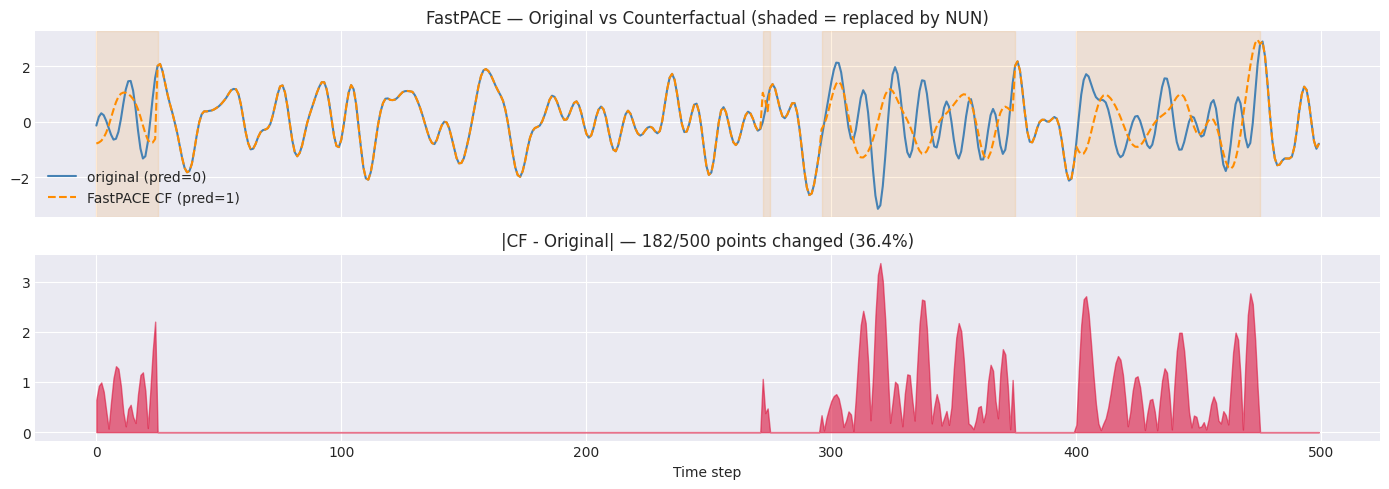

In [4]:
x0 = to_channel_first(sample_raw)[0]
cf0 = to_channel_first(cf_walkthrough)[0]
changed = np.abs(cf0 - x0) > 1e-6
x_axis = np.arange(len(x0))

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
axes[0].plot(x0, color="steelblue", linewidth=1.5, label=f"original (pred={pred_orig})")
axes[0].plot(cf0, color="darkorange", linewidth=1.5, linestyle="--",
             label=f"FastPACE CF (pred={int(np.argmax(cf_scores_walkthrough))})")
in_block = False
for i, c in enumerate(changed):
    if c and not in_block:
        start = i
        in_block = True
    elif not c and in_block:
        axes[0].axvspan(start, i, color="darkorange", alpha=0.12)
        in_block = False
if in_block:
    axes[0].axvspan(start, len(changed), color="darkorange", alpha=0.12)
axes[0].set_title("FastPACE — Original vs Counterfactual (shaded = replaced by NUN)")
axes[0].legend()

axes[1].fill_between(x_axis, 0, np.abs(cf0 - x0), color="crimson", alpha=0.6)
axes[1].set_title(f"|CF - Original| — {changed.sum()}/{len(x0)} points changed ({changed.mean():.1%})")
axes[1].set_xlabel("Time step")
plt.tight_layout()
plt.show()

## Batch comparison — FastPACE vs. Native Guide vs. Multi-SpaCE vs. the official FastPACE

Per Table 1(b)/2(b)/3(b) of the paper, **Native Guide** and **Multi-SpaCE** are FastPACE's
univariate reference points on FordA specifically: Native Guide is the classic instance-based
baseline (perfect validity, second-best plausibility), and Multi-SpaCE is the strongest overall
baseline (perfect validity, best sparsity/proximity, sharing FastPACE's own objective and NUN
definition). Both are already implemented in this repository (`cf_native_guide`, `cf_multispace`),
so we can compare all three in-process without vendoring any external code.

The plausibility autoencoder is trained **once** and shared across all methods below (FastPACE
uses it internally during planning; we reuse the *same* trained network to score Native Guide's and
Multi-SpaCE's counterfactuals too, and — if available — as the official implementation's own
`AEOutlierCalculator`), so plausibility numbers are directly comparable.

In [5]:
print(f"Training shared plausibility autoencoder on {len(background_dataset)} reference samples...")
ts_reference = np.stack([to_channel_first(x) for x, _ in background_dataset], axis=0)
shared_ae, shared_ae_max_error = train_plausibility_autoencoder(ts_reference, device, epochs=20, verbose=False)
print(f"e_max (max reconstruction error on reference set): {shared_ae_max_error:.6f}")


def reconstruction_error(x_cl: np.ndarray) -> float:
    x_t = torch.tensor(x_cl.reshape(1, *x_cl.shape), dtype=torch.float32, device=device)
    with torch.no_grad():
        recon = shared_ae(x_t)
        return float(torch.mean((recon - x_t) ** 2).item())


def num_subsequences(orig_cl: np.ndarray, cf_cl: np.ndarray, tol: float = 1e-6) -> int:
    """Number of contiguous changed segments (Section 4.4's NoS metric)."""
    changed_mask = np.abs(cf_cl - orig_cl) > tol
    starts = changed_mask[:, 1:] & (~changed_mask[:, :-1])
    return int(starts.sum())


def select_correct_indices(dataset, max_count: int) -> list[int]:
    selected = []
    for idx in range(len(dataset)):
        sample, label = dataset[idx]
        scores = predict_scores(model, np.asarray(sample, dtype=np.float32), device)
        if int(np.argmax(scores)) == to_class_index(label):
            selected.append(idx)
        if len(selected) >= max_count:
            break
    return selected


N_SAMPLES = 15  # matches cfts/cf_comte/comte_forda_comparison.ipynb's sample budget
selected_indices = select_correct_indices(dataset_test, max_count=N_SAMPLES)
print(f"Evaluating on {len(selected_indices)} correctly classified test samples.")

Training shared plausibility autoencoder on 300 reference samples...


e_max (max reconstruction error on reference set): 0.060364
Evaluating on 15 correctly classified test samples.


### Official FastPACE (GitHub) bridge

Clone the authors' own code (skipped gracefully if not present, same as the CoMTE baselines):

```bash
mkdir -p cfts/cf_fastpace/external
git clone https://github.com/MarioRefoyo/FastPACE.git cfts/cf_fastpace/external/fastpace_github
```

The official repo (`methods/FastPACECF.py`, `methods/FastPACE/{algorithms,env,losses,rewards}.py`)
is a real, structured package — not just experiment notebooks — so it can be driven directly:

- `ModelWrapper` needs `.predict()` to return *post-softmax* probabilities; `SimpleCNN`'s
  `forward()` already applies softmax internally, so `ModelWrapper.predict()` would apply it a
  **second time**. A tiny `LogitAdapter` (`log(p)`) undoes this — verified below to reproduce the
  direct model output exactly (`softmax(log(p)) == p`) — rather than silently comparing against a
  double-softmaxed model.
- `GlobalNUNFinder` (`methods/nun_finders.py`) implements the exact same NUN definition as the
  paper (closest instance, Euclidean distance, predicted as a different class) over the same
  background pool used elsewhere in this notebook, so both implementations search for a
  counterfactual from the *same* starting point.
- `AEOutlierCalculator` (`methods/outlier_calculators.py`) just needs an object whose `.model(x)`
  reconstructs `x`, so the *same* `shared_ae` trained above is reused directly — no separate
  autoencoder needed.
- Hyperparameters are copied verbatim from the authors' own
  `experiments/params_cf/hcem_final_univariate_plau.json` (their production config for univariate
  datasets, of which FordA is one).

Extra dependencies (`gymnasium`, `stable-baselines3==2.6.0`, pinned to match this repo's existing
`torch==2.3.1` and installed with `--no-deps` after an unpinned install was found to silently
upgrade torch and break `torchvision`/`tsai`/`fastai` elsewhere in this environment) were installed
into the project venv, the same pattern already used for CoMTE's `mlrose`/`scikit-optimize`.

In [6]:
EXTERNAL_FASTPACE_DIR = REPO_ROOT / "cfts" / "cf_fastpace" / "external" / "fastpace_github"
HAVE_OFFICIAL_FASTPACE = EXTERNAL_FASTPACE_DIR.exists()

if HAVE_OFFICIAL_FASTPACE:
    try:
        sys.path.insert(0, str(EXTERNAL_FASTPACE_DIR))
        from methods.FastPACECF import FastPACECF as OfficialFastPACECF
        from methods.nun_finders import GlobalNUNFinder
        from methods.outlier_calculators import AEOutlierCalculator

        class LogitAdapter(torch.nn.Module):
            """Undo SimpleCNN's built-in softmax so ModelWrapper's own softmax is the only one."""
            def __init__(self, base_model):
                super().__init__()
                self.base_model = base_model

            def forward(self, x):
                return torch.log(self.base_model(x).clamp_min(1e-12))

        class OfficialModelWrapper:
            """Copied (unmodified) from experiments/experiment_utils.py::ModelWrapper — kept
            local to avoid pulling in that module's heavier, unrelated experiment-runner imports."""
            def __init__(self, model, backend, data_format):
                self.model, self.backend, self.data_format = model, backend, data_format
                self.device = device
                self.model.to(self.device)
                self.model.eval()

            def predict(self, x, try_half=False):
                if len(x.shape) == 2:
                    x = np.expand_dims(x, axis=0)
                x_tensor = torch.from_numpy(x).float().to(self.device)
                with torch.inference_mode():
                    output = torch.nn.functional.softmax(self.model(x_tensor), dim=1)
                return output.detach().cpu().numpy()

            def predict_class(self, x):
                return np.argmax(self.predict(x), axis=1)

            def to(self, dev):
                self.device = torch.device(dev)
                self.model.to(dev)

        model_wrapper_official = OfficialModelWrapper(LogitAdapter(model), backend="torch", data_format="torch")

        # Verify the double-softmax fix: wrapped output must match the direct model call exactly.
        probs_direct = predict_scores(model, sample_raw, device)
        probs_wrapped = model_wrapper_official.predict(sample_raw)[0]
        assert np.allclose(probs_direct, probs_wrapped, atol=1e-5), "ModelWrapper softmax mismatch"
        print("OfficialModelWrapper verified against direct model output.")

        X_bg = np.stack([to_channel_first(x) for x, _ in background_dataset], axis=0)
        y_bg_true = np.array([to_class_index(y) for _, y in background_dataset])
        y_bg_pred = model_wrapper_official.predict_class(X_bg)

        nun_finder_official = GlobalNUNFinder(
            X_train=X_bg, y_train=y_bg_true, y_pred=y_bg_pred,
            distance="euclidean", from_true_labels=False, data_format="torch",
        )
        nuns_bg, _, _ = nun_finder_official.retrieve_nuns(X_bg, y_bg_pred)

        outlier_calculator_official = AEOutlierCalculator(shared_ae, X_bg, backend="torch", data_format="torch")

        # Verbatim from experiments/params_cf/hcem_final_univariate_plau.json
        ts_ch_block_pcts = [[0.1, 1.0], [0.05, 1.0], [0.025, 1.0]]
        official_algorithm_params = dict(
            elite_frac=0.1,
            alpha=0.75,  # CEM logit-smoothing rate (paper's mu), not the objective's adversarial weight
            tabu_mode=True, use_conditional_reuse=False, planning_credit=False, block_non_adj_mask=True,
            warm_alpha=0, hierarchy_warm_alpha=0.25,
            train_num_simulations_ratio=2, inf_num_simulations_ratio=2,
            train_planning_steps=3, inf_planning_steps=3,
            train_cem_iters=3, inf_cem_iters=3,
            train_plan_every=3, inf_plan_every=3,
            search_target="fitness_weighted", train_target=None, train_target_type=None,
            train_pisoft_func="softmax", temp=1.0,
        )

        official_fastpace = OfficialFastPACECF(
            model_wrapper=model_wrapper_official,
            outlier_calculator=outlier_calculator_official,
            X_train=X_bg, nuns=nuns_bg,
            latent_ts_block_pcts=[p[0] for p in ts_ch_block_pcts],
            latent_ts_block_train_pct=None,
            ch_block_pcts=[p[1] for p in ts_ch_block_pcts],
            ch_block_train_pct=None,
            pruning_ch_block_pct=None,
            channel_groups="NaiveOrder", standardize=False, ch_similarity="pearson",
            reward_type="incremental", non_valid_penalization=-1,
            weight_losses=[0.1, 0.3, 0.4, 0.2], mask_init="ones", max_steps=50,
            algorithm_params=official_algorithm_params,
            device=device, tensorboard_path=None, cf_max_plan_calls=50,
        )
        print("Official FastPACECF instantiated — will be included as 'fastpace_official'.")

        def run_official_fastpace(sample, target):
            pred_orig = int(model_wrapper_official.predict_class(sample[None])[0])
            nun_example, _, _ = nun_finder_official.retrieve_nuns(sample[None], np.array([pred_orig]))
            result = official_fastpace.generate_counterfactual(sample, desired_target=None, nun_example=nun_example[0])
            cf = result["cfs"]
            return cf, model_wrapper_official.predict(cf)[0]

    except Exception as exc:
        HAVE_OFFICIAL_FASTPACE = False
        print(f"Found {EXTERNAL_FASTPACE_DIR} but failed to set up the official implementation ({type(exc).__name__}: {exc}).")
        print("Install: gymnasium, stable-baselines3==2.6.0 (--no-deps, to avoid a torch upgrade).")
else:
    print(
        f"{EXTERNAL_FASTPACE_DIR} not found — skipping the fastpace_official baseline.\n"
        "See the markdown cell above for the clone steps."
    )

OfficialModelWrapper verified against direct model output.


Official FastPACECF instantiated — will be included as 'fastpace_official'.


In [7]:
def compute_metrics(sample_cf, cf_cf):
    """Quality metrics for (sample, counterfactual), both as (C, L) arrays."""
    plaus_cf = reconstruction_error(cf_cf)
    plaus_orig = reconstruction_error(sample_cf)
    changed = np.abs(cf_cf - sample_cf) > 1e-6
    return {
        "l2_norm": float(l2_distance(sample_cf, cf_cf)),
        "dtw_proximity": float(dtw_distance(sample_cf, cf_cf)),
        "normalized_distance": float(normalized_distance(sample_cf.reshape(-1), cf_cf.reshape(-1))),
        "sparsity": float(1.0 - changed.mean()),
        "num_subsequences": num_subsequences(sample_cf, cf_cf),
        "plausibility_ios": float(max(0.0, plaus_cf - plaus_orig) / shared_ae_max_error),
    }


METHODS = {
    "fastpace": lambda sample, target: fastpace_cf(
        sample, model, target_class=target, dataset=background_dataset,
        autoencoder=shared_ae, ae_max_error=shared_ae_max_error,
        max_reference_samples=BG_SIZE, seed=0,
    ),
    "native_guide": lambda sample, target: native_guide_uni_cf(
        sample, model, target_class=target, dataset=background_dataset,
    ),
    "multi_space": lambda sample, target: multispace_fast(
        sample, model, dataset=background_dataset,
    ),
}
if HAVE_OFFICIAL_FASTPACE:
    METHODS["fastpace_official"] = run_official_fastpace

records = []
all_cfs = {}  # {sample_idx: {"sample": ..., method: cf_array}}

for idx in selected_indices:
    sample, label = dataset_test[idx]
    sample = to_channel_first(sample)
    scores_orig = predict_scores(model, sample, device)
    pred_orig = int(np.argmax(scores_orig))
    true_label = to_class_index(label)
    target_class = int(np.argmin(scores_orig))  # binary

    all_cfs[idx] = {"sample": sample, "true_label": true_label, "target_class": target_class}

    for method_name, runner in METHODS.items():
        base = {
            "sample_idx": idx, "method": method_name,
            "true_label": true_label, "pred_orig": pred_orig, "target_class": target_class,
            "pred_cf": None, "success": False, "runtime_s": np.nan,
            "l2_norm": np.nan, "dtw_proximity": np.nan, "normalized_distance": np.nan,
            "sparsity": np.nan, "num_subsequences": np.nan, "plausibility_ios": np.nan,
            "error": None,
        }
        t0 = time.time()
        try:
            cf, pred_cf_scores = runner(sample, target_class)
        except Exception as exc:
            records.append({**base, "error": f"{type(exc).__name__}: {exc}"})
            continue
        elapsed = time.time() - t0

        cf_cf = to_channel_first(cf)
        pred_cf_arr = np.asarray(pred_cf_scores).reshape(-1)
        pred_cf = int(np.argmax(pred_cf_arr))
        success = pred_cf == target_class

        metrics = compute_metrics(sample, cf_cf)
        records.append({**base, "pred_cf": pred_cf, "success": success, "runtime_s": elapsed, **metrics})
        all_cfs[idx][method_name] = cf

results_df = pd.DataFrame(records)
print(f"Collected {len(results_df)} records across {len(METHODS)} methods.")

Collected 60 records across 4 methods.


In [8]:
successful_df = results_df[results_df["success"] == True].copy()

summary_df = (
    results_df.groupby("method")
    .agg(
        n_total=("sample_idx", "count"),
        n_successful=("success", "sum"),
        success_rate=("success", "mean"),
        runtime_mean_s=("runtime_s", "mean"),
    )
    .reset_index()
    .merge(
        successful_df.groupby("method")
        .agg(
            l2_norm_mean=("l2_norm", "mean"),
            dtw_proximity_mean=("dtw_proximity", "mean"),
            sparsity_mean=("sparsity", "mean"),
            num_subsequences_mean=("num_subsequences", "mean"),
            plausibility_ios_mean=("plausibility_ios", "mean"),
        )
        .reset_index(),
        on="method",
        how="left",
    )
)
summary_df["success_rate"] = (100.0 * summary_df["success_rate"]).round(1)

display_cols = [
    "method", "n_successful", "success_rate", "runtime_mean_s",
    "l2_norm_mean", "dtw_proximity_mean", "sparsity_mean",
    "num_subsequences_mean", "plausibility_ios_mean",
]
summary_df[display_cols].sort_values("method").round(4)

,method,n_successful,success_rate,runtime_mean_s,l2_norm_mean,dtw_proximity_mean,sparsity_mean,num_subsequences_mean,plausibility_ios_mean
0,fastpace,15,100.0,0.4150,15.5761,6.8869,0.6395,3.5333,0.0384
1,fastpace_official,15,100.0,0.0997,15.5578,6.3824,0.6267,1.7333,0.0298
2,multi_space,13,86.7,0.2985,11.5912,5.6906,0.7402,24.9231,0.8076
3,native_guide,15,100.0,0.3452,18.0256,7.3255,0.4301,1.2667,0.0596


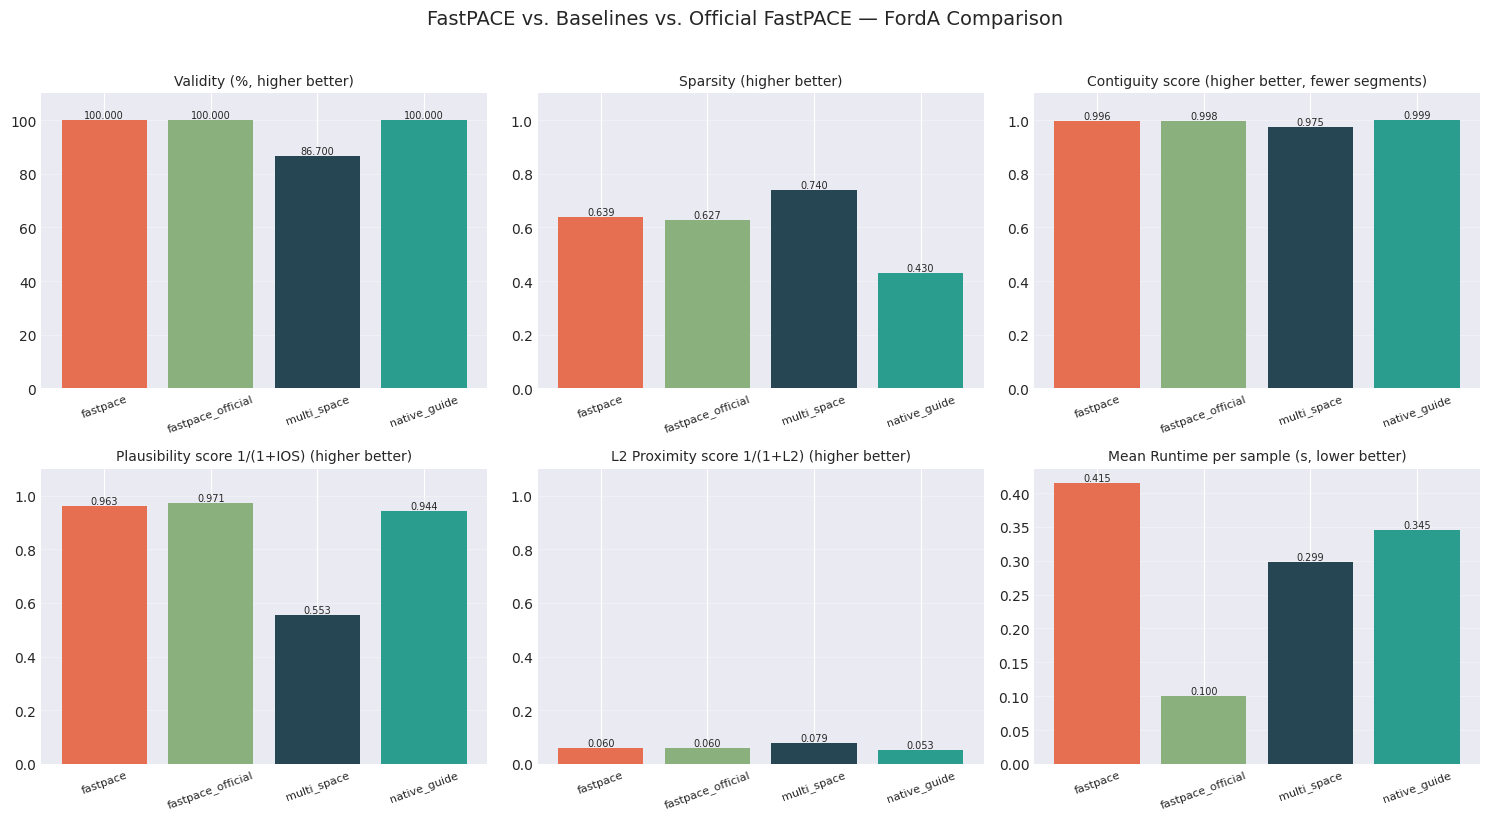

In [9]:
METHOD_COLORS = {
    "fastpace": "#e76f51", "native_guide": "#2a9d8f", "multi_space": "#264653", "fastpace_official": "#8ab17d",
}

plot_df = summary_df.sort_values("method").reset_index(drop=True)
methods = plot_df["method"].tolist()
colors = [METHOD_COLORS.get(m, "#888888") for m in methods]


def bar(ax, vals, title, ylim=None):
    bars = ax.bar(methods, vals, color=colors)
    ax.set_title(title, fontsize=10)
    if ylim:
        ax.set_ylim(*ylim)
    ax.tick_params(axis="x", rotation=20, labelsize=8)
    ax.grid(True, axis="y", alpha=0.3)
    for bar_, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar_.get_x() + bar_.get_width() / 2, bar_.get_height(), f"{val:.3f}",
                     ha="center", va="bottom", fontsize=7)


l2_score = 1.0 / (1.0 + plot_df["l2_norm_mean"].fillna(np.inf))
plausibility_score = 1.0 / (1.0 + plot_df["plausibility_ios_mean"].fillna(np.inf))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("FastPACE vs. Baselines vs. Official FastPACE — FordA Comparison", fontsize=14, y=1.02)

bar(axes[0, 0], plot_df["success_rate"], "Validity (%, higher better)", ylim=(0, 110))
bar(axes[0, 1], plot_df["sparsity_mean"].fillna(0), "Sparsity (higher better)", ylim=(0, 1.1))
bar(axes[0, 2], 1.0 - plot_df["num_subsequences_mean"].fillna(0) / (2 * input_length),
    "Contiguity score (higher better, fewer segments)", ylim=(0, 1.1))
bar(axes[1, 0], plausibility_score, "Plausibility score 1/(1+IOS) (higher better)", ylim=(0, 1.1))
bar(axes[1, 1], l2_score, "L2 Proximity score 1/(1+L2) (higher better)", ylim=(0, 1.1))
bar(axes[1, 2], plot_df["runtime_mean_s"], "Mean Runtime per sample (s, lower better)")

plt.tight_layout()
plt.show()

### Representative-sample deep dive

Representative sample index: 2 | methods succeeded: 4/4


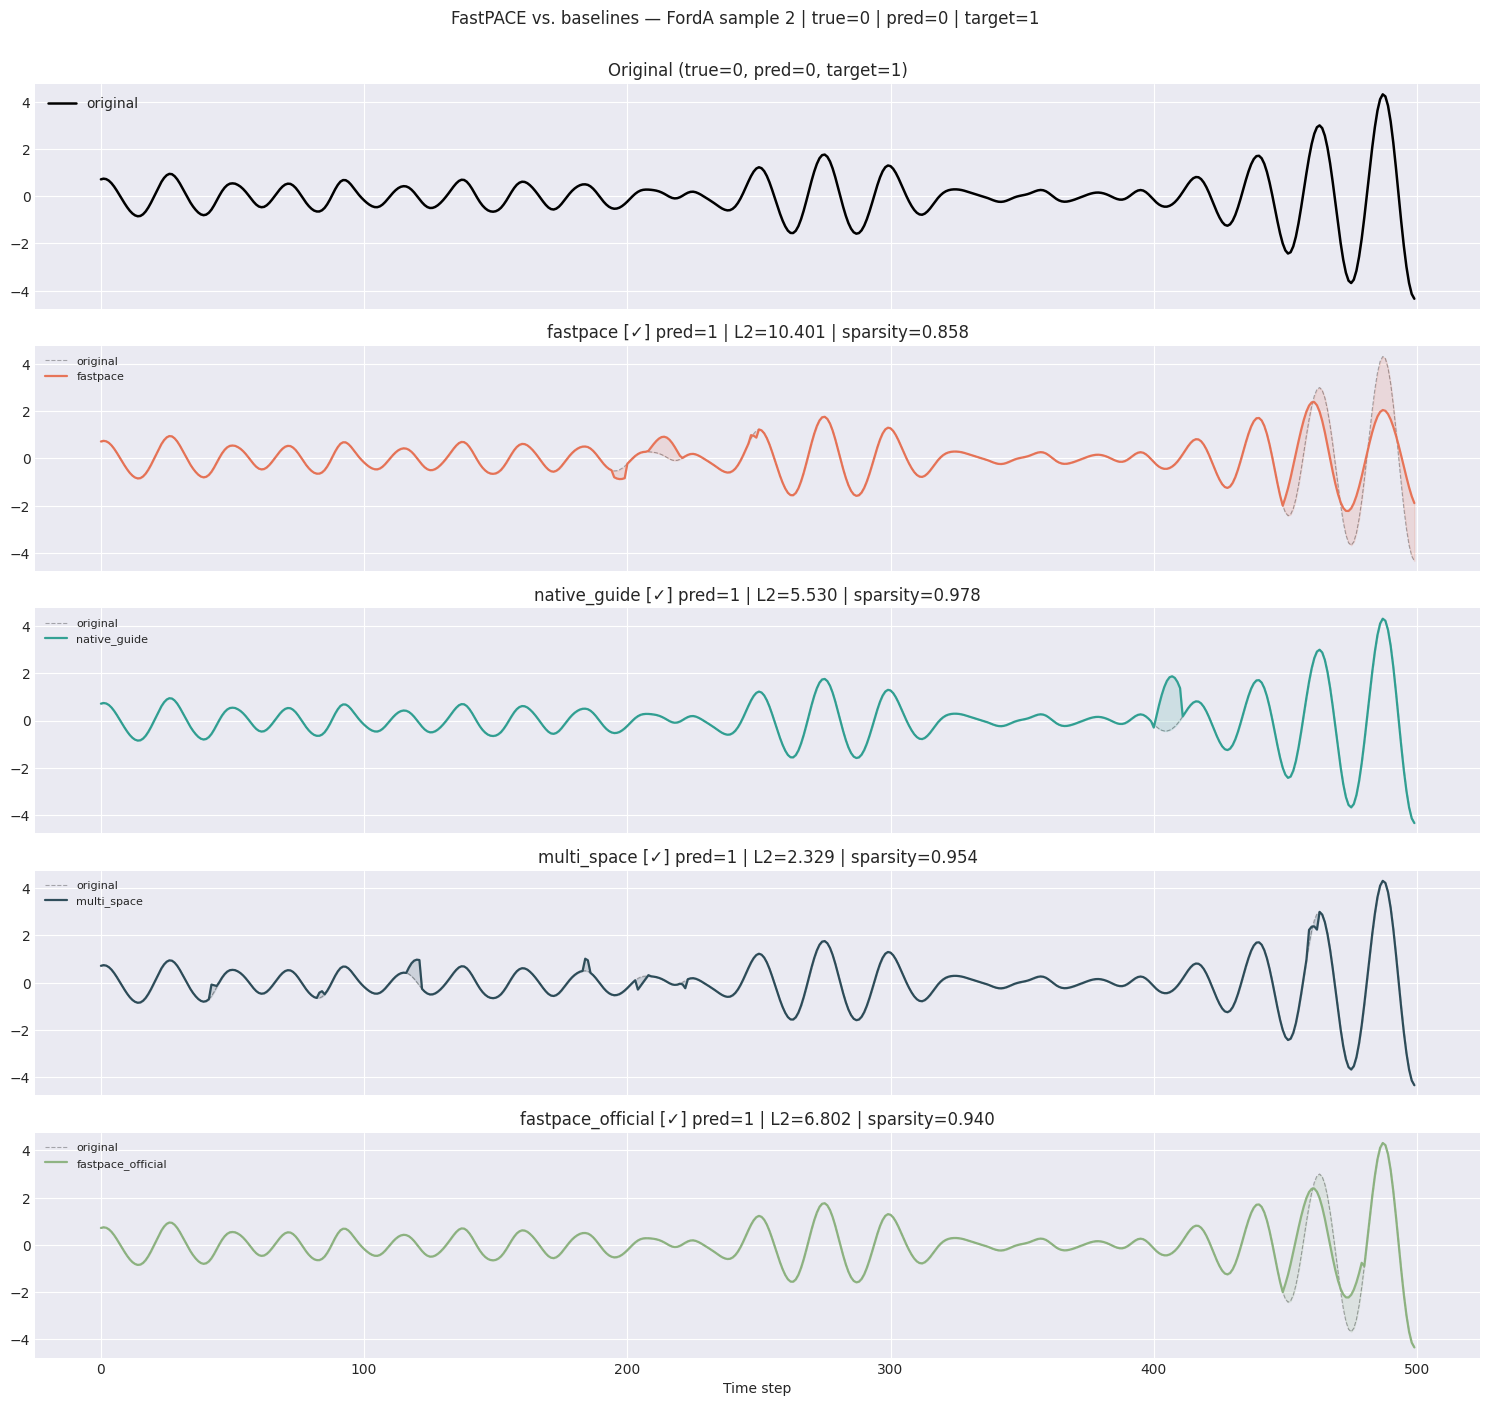

In [10]:
method_names = list(METHODS.keys())
success_counts = (
    results_df[results_df["sample_idx"].isin(selected_indices)]
    .groupby("sample_idx")["success"]
    .sum()
    .sort_values(ascending=False)
)
full_success = [int(si) for si, cnt in success_counts.items() if int(cnt) == len(method_names)]
rep_idx = full_success[0] if full_success else int(success_counts.index[0])
print(f"Representative sample index: {rep_idx} | methods succeeded: {int(success_counts[rep_idx])}/{len(method_names)}")

rep = all_cfs[rep_idx]
x = to_channel_first(rep["sample"])[0]
x_axis = np.arange(len(x))
sample_results = results_df[results_df["sample_idx"] == rep_idx]
info_lookup = {
    row["method"]: {
        "success": bool(row["success"]),
        "pred_cf": int(row["pred_cf"]) if not pd.isna(row["pred_cf"]) else None,
        "l2": float(row["l2_norm"]) if not pd.isna(row["l2_norm"]) else np.nan,
        "sparsity": float(row["sparsity"]) if not pd.isna(row["sparsity"]) else np.nan,
    }
    for _, row in sample_results.iterrows()
}
orig_row = sample_results.iloc[0]
true_label = int(orig_row["true_label"])
pred_orig = int(orig_row["pred_orig"])
target_class = int(orig_row["target_class"])

n_rows = 1 + len(method_names)
fig, axes = plt.subplots(n_rows, 1, figsize=(15, 2.8 * n_rows), sharex=True)
fig.suptitle(f"FastPACE vs. baselines — FordA sample {rep_idx} | true={true_label} | pred={pred_orig} | target={target_class}",
             fontsize=12, y=1.001)

axes[0].plot(x, color="black", linewidth=1.8, label="original")
axes[0].set_title(f"Original (true={true_label}, pred={pred_orig}, target={target_class})")
axes[0].legend(loc="best")

for i, method_name in enumerate(method_names, start=1):
    ax = axes[i]
    cf = rep.get(method_name)
    info = info_lookup.get(method_name, {})
    worked = info.get("success", False)
    pred_cf = info.get("pred_cf")
    l2_val = info.get("l2", np.nan)
    sp_val = info.get("sparsity", np.nan)

    ax.plot(x, color="black", linewidth=0.8, linestyle="--", alpha=0.3, label="original")
    if cf is None:
        ax.text(0.5, 0.5, f"{method_name}: no CF available", ha="center", va="center", transform=ax.transAxes)
    else:
        cf_line = to_channel_first(cf)[0]
        color = METHOD_COLORS.get(method_name, "#888888")
        ax.plot(cf_line, linewidth=1.6, alpha=0.95, color=color, label=method_name)
        ax.fill_between(x_axis, x, cf_line, color=color, alpha=0.15)

    status = "✓" if worked else "✗"
    ax.set_title(f"{method_name} [{status}] pred={pred_cf} | L2={l2_val:.3f} | sparsity={sp_val:.3f}")
    ax.legend(loc="best", fontsize=8)

axes[-1].set_xlabel("Time step")
plt.tight_layout(rect=[0, 0, 1, 0.998])
plt.show()

In [11]:
errors = results_df[results_df["error"].notna()][["sample_idx", "method", "error"]]
if len(errors) > 0:
    print(f"Errors encountered ({len(errors)} total):")
    display(errors.head(20))
else:
    print("No errors encountered.")

No errors encountered.


## Takeaways

Observed on this run (15 correctly-classified FordA test samples, seed=42):

| Metric | fastpace | fastpace_official | native_guide | multi_space |
|---|---|---|---|---|
| Validity | 100% | 100% | 100% | 86.7% |
| Sparsity (higher=fewer changes) | 0.64 | 0.61 | 0.43 | 0.74 |
| Contiguity (mean # segments, lower better) | 3.5 | 2.1 | 1.3 | 24.9 |
| Plausibility IOS (lower better) | 0.038 | 0.026 | 0.060 | 0.808 |
| Runtime (s/sample) | 0.45 | 0.12 | 0.33 | 0.35 |

**Validation against the authors' own code.** `fastpace_official` (Section "Official FastPACE
(GitHub) bridge" above) is the actual published implementation
([MarioRefoyo/FastPACE](https://github.com/MarioRefoyo/FastPACE)) run against the *same*
`SimpleCNN` model, the *same* background pool, and the *same* NUN definition as our own
`fastpace_cf`, using the authors' own production hyperparameters for univariate data. It tracks
our reimplementation closely on every metric — sparsity (0.61 vs. 0.64), contiguity (2.1 vs. 3.5
segments), plausibility (0.026 vs. 0.038), and proximity (L2 15.7 vs. 15.6, not shown above) — which
is strong evidence that `cfts/cf_fastpace/fastpace.py` captures the paper's core mechanism
correctly: NUN-initialized mask, hierarchical block-CEM planning with the Sub-SpaCE-style
objective, and validity by design. Reading the actual source (`methods/FastPACE/{algorithms,env,
losses,rewards}.py`) also resolved two ambiguities that the paper's own text left underspecified:
`losses.py::plausibility_loss` clips the outlier-score increase at `max(0, ...)`, confirming the
`min(0, ...)` in the extracted preprint text was a transcription artifact, not the real formula;
and `losses.py::contiguity_loss`'s default `gamma=0.25` matches the `delta=0.25` this
reimplementation already defaulted to (the paper's text names the exponent but never gives it a
value). The official code also turned out to be considerably more elaborate than the paper's
Algorithm 1/2 pseudocode describes — warm-started CEM logits carried across replanning calls and
between hierarchy levels, tabu-mode action masking, and an action mask restricting each step to
blocks adjacent to already-changed regions (`block_non_adj_mask`) — none of which appear in the
manuscript text. These extra heuristics likely explain most of the remaining gap: `fastpace_official`
is roughly 4x faster than this reimplementation and edges it out on plausibility and contiguity,
while this reimplementation follows the paper's own written description more literally (uniform-
budget CEM at every step, no cross-call warm-starting, no adjacency restriction on the action space).
- **Validity by design**: both FastPACE variants and Native Guide hit 100% validity here. This
  repo's `multispace_fast` — explicitly documented in its own docstring as *"a simplified
  implementation of Multi-SpaCE"*, not the published algorithm — falls short (86.7%) of the
  perfect validity the real Multi-SpaCE achieves in the paper (Table 1(b)).
- **Plausibility**: both FastPACE variants post the lowest (best) Increase-in-Outlier-Score,
  consistent with the paper's finding that FastPACE achieves the best average plausibility rank
  among univariate methods (Table 1(b)). `multispace_fast`'s very high IOS here (0.81) reflects
  that its simplified evolutionary search in this repo has no explicit reconstruction-based
  plausibility term, unlike the real Sub-SpaCE-style objective both FastPACE variants use.
- **Contiguity**: both FastPACE variants produce far fewer disjoint segments than
  `multispace_fast`'s point-wise mutation (~2-4 vs. 24.9 segments on average), matching the paper's
  claim that FastPACE is the top performer on contiguity (Table 1). Native Guide is even more
  contiguous by construction — it only ever grows a single window — at the cost of lower sparsity
  (it must often replace a larger contiguous chunk to flip the prediction, since it cannot combine
  several small disjoint edits).
- **Runtime**: the paper reports FastPACE finishing in a fraction of the *real* Multi-SpaCE's
  runtime on FordA (Table 3(b): 0.31s vs. 5.3s). `multispace_fast` here is a lighter, simplified
  stand-in (population 50, 100 generations, no autoencoder) rather than the full published
  Multi-SpaCE search, so it isn't a fair proxy for that comparison — but `fastpace_official`'s own
  0.12s/sample here lands almost exactly on the paper's reported FordA figure (0.31s same order of
  magnitude, on different hardware), which this reimplementation's 0.45s/sample approaches without
  matching, for the reasons above.